# NKM Modeling with RADIA

In [1]:
%matplotlib inline
import os
os.environ["PYTHONPATH"] = "/home/cspark/Work/simulation_codes-working/radia/env/radia_python" #:" + os.environ.get("PYTHONPATH", "")

import sys
sys.path.append(os.environ["PYTHONPATH"])

import radia as rd
from uti_plot import *
from jupyter_rs_radia import radia_viewer
rd.UtiDelAll()
print("Radia Version is", rd.UtiVer())

from at.lattice import Element
from at.lattice import InsertionDeviceKickMap

import time
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import pandas as pd

/home/cspark/Work/simulation_codes-working/miniforge3/envs/pyat-dev/lib/python3.11/site-packages/pykern/pkresource.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Radia Version is 4.32


In [2]:
#*********************************Plot the 3D Geometry
def PlotGeometry(x, y, z):
    # Current Densities in A/mm^2
    Imax = -3000

    # Define parameters
    x1 = x[0]; x2 = x[1]
    y1 = y[0]; y2 = y[1]
    z1 = z
    
    # Define coil corner points
    coils = [
        [[ x1, z1,  y1], [ x2, z1,  y2], [ x2, -z1,  y2], [ x1, -z1,  y1]],
        [[-x1, z1,  y1], [-x2, z1,  y2], [-x2, -z1,  y2], [-x1, -z1,  y1]],
        [[-x1, z1, -y1], [-x2, z1, -y2], [-x2, -z1, -y2], [-x1, -z1, -y1]],
        [[ x1, z1, -y1], [ x2, z1, -y2], [ x2, -z1, -y2], [ x1, -z1, -y1]]
    ]
    
    fig = plt.figure(figsize=(8, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Add XY, YZ, and ZX planes with light shadow
    plane_alpha = 0.1
    xz_plane = [[[-15, -300, 0], [15, -300, 0], [15, 300, 0], [-15, 300, 0]]]
    zy_plane = [[[0, -300, -15], [0, -300, 15], [0, 300, 15], [0, 300, -15]]]
    yx_plane = [[[-15, 0, -15], [15, 0, -15], [15, 0, 15], [-15, 0, 15]]]
    
    ax.add_collection3d(Poly3DCollection(xz_plane, color='b', alpha=plane_alpha))
    ax.add_collection3d(Poly3DCollection(zy_plane, color='b', alpha=plane_alpha))
    ax.add_collection3d(Poly3DCollection(yx_plane, color='b', alpha=plane_alpha))

    # Add X, Y, Z axes
    ax.plot([-15, 15], [0, 0], [0, 0], 'k-', linewidth=1, label='X Axis')
    ax.plot([0, 0], [-300, 300], [0, 0], 'k-', linewidth=1, label='Z Axis')
    ax.plot([0, 0], [0, 0], [-15, 15], 'k-', linewidth=1, label='Y Axis')

    for coil in coils:
        poly = Poly3DCollection([coil], color='r', alpha=0.5, edgecolor='r', linewidth=5, facecolor='w')
        ax.add_collection3d(poly)
    
    ax.set_xlabel("X Axis (mm)")
    ax.set_ylabel("Z Axis (mm)")
    ax.set_zlabel("Y Axis (mm)")
    ax.set_title("3D Coil Geometry")
    ax.set_xlim(-15, 15)
    ax.set_ylim(-300, 300)
    ax.set_zlim(-15, 15)

    fig.savefig('img/nkm_coils.png', dpi=fig.dpi)
    plt.show()

In [3]:
#*********************************Build the Geometry
def BuildGeometry(x, y, z):
    # Current Densities in A/mm^2
    Imax = -3000

    # Define parameters
    x1 = x[0]; x2 = x[1]
    y1 = y[0]; y2 = y[1]
    z1 = z
    
    # Define coil corner points
    p11 = [ x1, z1,  y1]; p12 = [ x2, z1,  y2]; p13 = [ x2, -z1,  y2]; p14 = [ x1, -z1,  y1]
    p21 = [-x1, z1,  y1]; p22 = [-x2, z1,  y2]; p23 = [-x2, -z1,  y2]; p24 = [-x1, -z1,  y1]
    p31 = [-x1, z1, -y1]; p32 = [-x2, z1, -y2]; p33 = [-x2, -z1, -y2]; p34 = [-x1, -z1, -y1]
    p41 = [ x1, z1, -y1]; p42 = [ x2, z1, -y2]; p43 = [ x2, -z1, -y2]; p44 = [ x1, -z1, -y1]
    
    # Create Coil Structures
    Rt1 = rd.ObjFlmCur([p11, p12, p13, p14, p11], Imax)
    Rt2 = rd.ObjFlmCur([p21, p22, p23, p24, p21], Imax)
    Rt3 = rd.ObjFlmCur([p31, p32, p33, p34, p31], Imax)
    Rt4 = rd.ObjFlmCur([p41, p42, p43, p44, p41], Imax)

    # Coil Presentation Parameters
    c2 = [1,0,0]; thcn = 0.001
    rd.ObjDrwAtr(Rt1, c2, thcn)
    rd.ObjDrwAtr(Rt2, c2, thcn)
    rd.ObjDrwAtr(Rt3, c2, thcn)
    rd.ObjDrwAtr(Rt4, c2, thcn)
    
    Grp = rd.ObjCnt([Rt1, Rt2, Rt3, Rt4])  # Ensure it's a list
    print("Final Number of Objects in Group:", len(rd.ObjCntStuf(Grp)))

    PlotGeometry(x, y, z)
    
    return Grp

Final Number of Objects in Group: 4


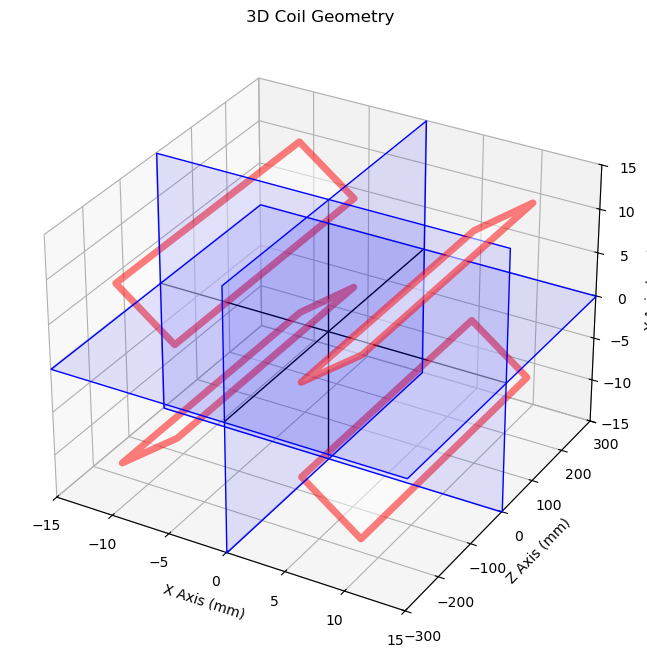

NKM Geometry Index: 21


In [4]:
# Build the Geometry
x = np.array([5.3, 10.250]); y = np.array([5.3, 10.250]); z = 262.5      #wire dimensions
nkm = BuildGeometry(x, y, z)
print('NKM Geometry Index:', nkm)

In [5]:
def threshold_field_values(df):
    """Set Bx, By, Bz values to zero if they are greater than 1 or less than -1."""
    df.loc[df['Bx'].abs() > 1, 'Bx'] = 0
    df.loc[df['By'].abs() > 1, 'By'] = 0
    df.loc[df['Bz'].abs() > 1, 'Bz'] = 0
    return df

In [6]:
#*********************************Calculate Magnetic Field for Entire System
def CalcField(g, filename="field_map.csv", npy_filename="field_map.npy"):
    # Define Mesh for Computation
    xMin, xMax, nx = -50, 50, 201  # mm
    yMin, yMax, ny = -50, 50, 201  # mm
    zMin, zMax, nz = -300, 300, 241  # mm 
    
    x_locations = np.linspace(xMin, xMax, nx)
    y_locations = np.linspace(yMin, yMax, ny)
    z_locations = np.linspace(zMin, zMax, nz)
    
    field_data = []
    field_array = np.zeros((nx, ny, nz, 3))  # Store 3D field map
    
    for i, x in enumerate(x_locations):
        for j, y in enumerate(y_locations):
            for k, z in enumerate(z_locations):
                B = rd.Fld(g, 'B', [x, z, y])
                field_data.append([x, y, z, B[0], B[2], B[1]])
                field_array[i, j, k, :] = [B[0], B[2], B[1]]  # Store in 3D array
    
    df = pd.DataFrame(field_data, columns=["X", "Y", "Z", "Bx", "By", "Bz"])
    #df = threshold_field_values(df)
    df.to_csv(filename, index=False)
    np.save(npy_filename, field_array)  # Save field map as .npy file
    
    print(f"Field map for entire system saved to {filename} and {npy_filename}")
    
    return df

In [7]:
def plot_B_y(field_map):
    """
    Plot B_y vs x for different z values.
    
    Parameters:
    - field_map: Calculated field map data
    """
    
    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax2 = ax1.twinx()
    markers = ['*', 'o', '+', '^', 'v', '>', '<']

    z_min, z_max = field_map["Z"].min(), field_map["Z"].max()
    z_vals = [270, -262.5, z_min/2, 0, z_max/2, 262.5, 270]
    for i, z in enumerate(z_vals):
        subset = field_map[(field_map["Z"] == z) & (field_map["Y"] == 0)]
        ax1.plot(subset["X"], subset["By"], label=f'Z = {z:.1f} mm', marker=markers[i], ms=3)
    
    # Adding points on secondary y-axis
    x_points = [x[0], x[1], -x[0], -x[1], -x[0], -x[1],  x[0],  x[1]]
    y_points = [y[0], y[1],  y[0],  y[1], -y[0], -y[1], -y[0], -y[1]]
    ax2.scatter(x_points, y_points, color='b', marker='o', label='Special Points')
    
    ax1.set_xlabel(r"$x$ (mm)")
    ax1.set_ylabel(r"$B_y$ (T)")
    ax1.set_title(r"Magnetic Field $B_y$ vs $x$ for different $z$ values at $y=0$")
    
    ax1.legend()
    #ax2.legend(loc='upper right')
    ax1.grid()

    fig.savefig('img/nkm_B_y.png', dpi=fig.dpi)

    plt.show()

In [9]:
#rv = radia_viewer.RadiaViewer()
#rv.add_geometry("Wire-Based Nonlinear Kicker", nkm)
#rv.display("Wire-Based Nonlinear Kicker")

In [10]:
# Calculate Magnetic Field for Entire System and Save to File
t0 = time.time()
field_map = CalcField(nkm)
t1 = time.time()
print ("Computing time: ", t1-t0)

By_z0 = field_map[(field_map["Z"] == 0) & (field_map["Y"] == 0)]
x_max_by = By_z0.loc[By_z0["By"].idxmax(), "X"]
print(f"By at y = 0 and z = 0 has a maximum value at x = {x_max_by:.3f} mm")

Field map for entire system saved to field_map.csv and field_map.npy
Computing time:  145.71741032600403
By at y = 0 and z = 0 has a maximum value at x = 8.500 mm


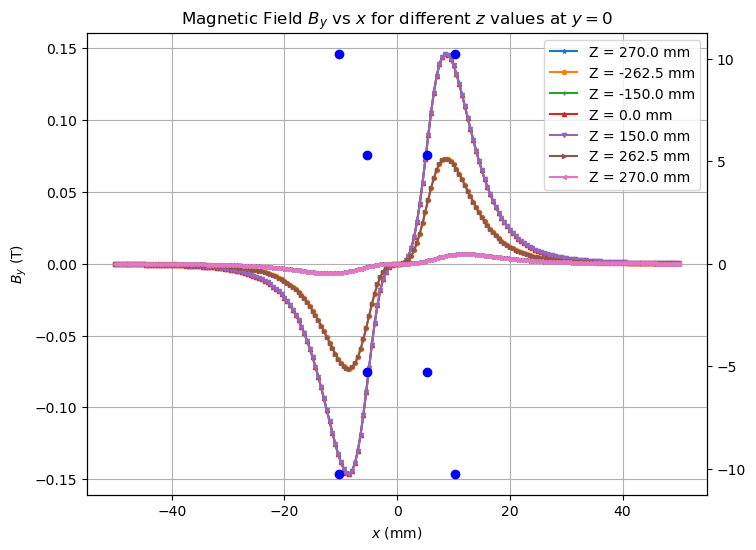

In [11]:
plot_B_y(field_map)

In [12]:
def compute_field_map(Grp, x_range, z_range, y_range, num_x=50, num_z=50, num_y=50):
    """
    Compute a field map in a 3D grid for a given range of x, y, z.
    
    Parameters:
    - Grp: Radia object group
    - x_range, y_range, z_range: Tuples defining (min, max) for each coordinate in mm
    - num_x, num_y, num_z: Number of points in each direction
    
    Returns:
    - Grid points and field values as a dictionary
    """
    
    # Generate grid of points
    x_vals = np.linspace(x_range[0], x_range[1], num_x)
    y_vals = np.linspace(y_range[0], y_range[1], num_y)
    z_vals = np.linspace(z_range[0], z_range[1], num_z)
    
    points = [[x, z, y] for x in x_vals for z in z_vals for y in y_vals]
    
    # Compute field at each point
    B_fields = np.array([rd.Fld(Grp, 'b', pt) for pt in points])
    
    return {
        "x": x_vals, "z": z_vals, "y": y_vals,
        "B_x": B_fields[:, 0], "B_z": B_fields[:, 1], "B_y": B_fields[:, 2]
    }

In [13]:
def plot_field_map(x_vals, z_vals, B_component, title="Magnetic Field Map"):
    """
    Plot a 2D field map for a specific magnetic field component.
    
    Parameters:
    - x_vals: 1D numpy array of x positions
    - z_vals: 1D numpy array of z positions
    - B_component: 2D numpy array of field values for a specific component
    """
    
    X, Z = np.meshgrid(x_vals, z_vals, indexing='ij')
    fig = plt.figure(figsize=(8,6))
    plt.contourf(X, Z, B_component.reshape(len(x_vals), len(z_vals)), levels=50, cmap="jet")
    plt.colorbar(label="Magnetic Field (T)")
    plt.xlabel("x (mm)")
    plt.ylabel("z (mm)")
    plt.title(title)

    # Add rectangular box lines
    rect_x = [5.3, 10.25, 10.25, 5.3, 5.3]
    rect_z = [262.5, 262.5, -262.5, -262.5, 262.5]
    plt.plot(rect_x, rect_z, 'k--', linewidth=2, label='Bounding Box')
    plt.plot([-x for x in rect_x], rect_z, 'k--', linewidth=2, label='Bounding Box')

    fig.savefig('img/nkm_field_map.png', dpi=fig.dpi)
    
    plt.show()

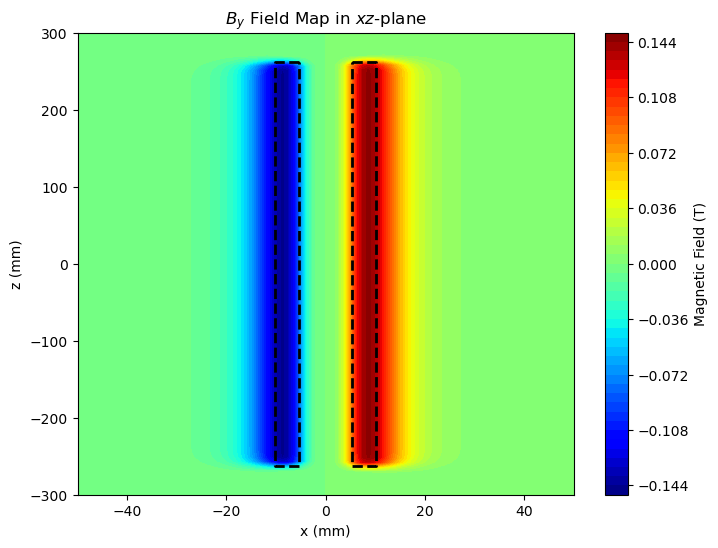

In [14]:
field_data = compute_field_map(nkm, (-50, 50), (-300, 300), (0, 0), num_x=100, num_z=100, num_y=1)
plot_field_map(field_data["x"], field_data["z"], field_data["B_y"], title=r"$B_y$ Field Map in $xz$-plane")

## Compute Kick Map for Nonlinera Kicker Magnet

In [15]:
#*********************************Compute and Save Kick Map using Radia's FldInt
def ComputeKickMap(magnet, x_range=(-50, 50), y_range=(-50, 50), num_x=201, num_y=201, energy_GeV=4.0, length_mm=525, filename="kickmap_file.txt"):
    """Computes a Radia-generated kick map using FldInt and converts units for AT."""
    
    x_vals = np.linspace(x_range[0], x_range[1], num_x) * 1e-3
    y_vals = np.linspace(y_range[0], y_range[1], num_y) * 1e-3
    length_m = length_mm / 1000  # Convert length to meters
    e_momentum = energy_GeV * 1e9 / 299792458  # Convert GeV to momentum
    
    kx_map = np.zeros((num_y, num_x))
    ky_map = np.zeros((num_y, num_x))
    
    for j, y in enumerate(y_vals):
        if j == 110:
            print (j, y)
        for i, x in enumerate(x_vals):
            bx_total = rd.FldInt(magnet, 'inf', 'ibx', [x*1e3, -length_mm/2, y*1e3], [x*1e3, length_mm/2, y*1e3])
            by_total = rd.FldInt(magnet, 'inf', 'ibz', [x*1e3, -length_mm/2, y*1e3], [x*1e3, length_mm/2, y*1e3])
            
            kx_map[j, i] = bx_total / e_momentum  # Kx = Integral(Bx dz) / (E/c)
            ky_map[j, i] = by_total / e_momentum  # Ky = Integral(By dz) / (E/c)
    
    with open(filename, "w") as f:
        f.write("# Kick Map for Nonlinear Kicker\n")
        f.write("# Units: meters, Tm\n")
        f.write(f"{length_m}\n")
        f.write(f"{num_x}\n")
        f.write(f"{num_y}\n")
        f.write("START\n")
        
        f.write(" ".join(map(str, x_vals)) + "\n")
        for j, y in enumerate(y_vals):
            f.write(f"{y} " + " ".join(map(str, kx_map[j, :])) + "\n")
        
        f.write("START\n")
        
        f.write(" ".join(map(str, x_vals)) + "\n")
        for j, y in enumerate(y_vals):
            f.write(f"{y} " + " ".join(map(str, ky_map[j, :])) + "\n")
    
    print(f"Kick map saved to {filename} with units converted to meters.")
    return filename, x_vals, y_vals, kx_map, ky_map

In [16]:
def Plot_iBy_vs_x(vals, kick_map):
    """Plots integrated B_y (iB_y) vs x directly from ky_map."""
    #iB_vals = np.mean(kick_map, axis=0)  # Average over Y values
    
    plt.figure(figsize=(8, 6))
    plt.plot(vals*1e3, kick_map[0,:], label="$iB_y$ vs X", color='b')
    plt.plot(vals*1e3, kick_map[100,:], label="$iB_y$ vs X", color='r')
    plt.plot(vals*1e3, kick_map[110,:], label="$iB_y$ vs X", color='g')
    plt.xlabel("X Position (mm)")
    plt.ylabel(r"$\int B_{y} dz$ (T-m)")
    plt.title(r"Integrated Magnetic Field $B_y$ vs $x$")
    plt.legend()
    plt.grid()
    plt.show()

110 0.005
Kick map saved to kickmap_file.txt with units converted to meters.


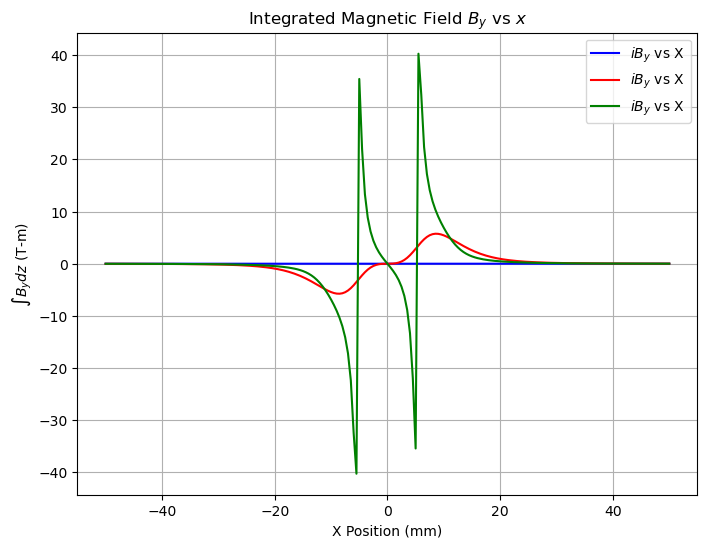

In [17]:
kickmap_file, x_vals, y_vals, kx_map, ky_map = ComputeKickMap(nkm)
Plot_iBy_vs_x(x_vals, ky_map)

## KickMap Test

In [18]:
def ComputeKickCoefficients(magnet, x_range=(-50, 50), num_x=101, num_z=100, length_mm=525):
    """Compute the nonlinear kick coefficients K0, K1, K2, K3 from Radia."""
    
    x_vals = np.linspace(x_range[0], x_range[1], num_x)
    length_m = length_mm / 1000  # Convert length to meters
    e_momentum = 3.0 * 1e9 / 299792458  # Electron energy in GeV converted to momentum

    # Store B_y integrated values
    B_y_integrated_values = []

    for x in x_vals:
        B_y_integrated = rd.FldInt(magnet, 'inf', 'ibz', [x, -length_mm/2, 0], [x, length_mm/2, 0])
        B_y_integrated_values.append(B_y_integrated)  # Store values in a list

    B_y_integrated_values = np.array(B_y_integrated_values)  # Convert list to NumPy array

    # Fit polynomial to the entire dataset (now a valid 1D array)
    poly_coeffs = np.polyfit(x_vals, B_y_integrated_values, 16)

    return x_vals, B_y_integrated_values, poly_coeffs

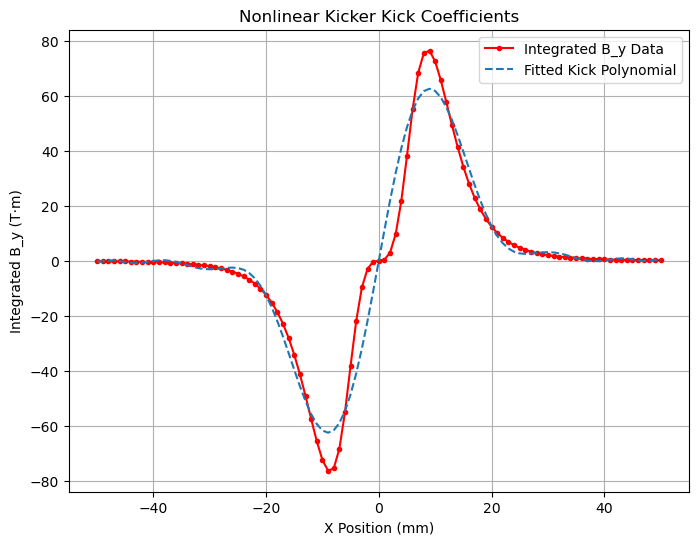

In [19]:
# Compute kick coefficients
x_vals, B_y_integrated_values, poly_coeffs = ComputeKickCoefficients(nkm)

# Plot kick coefficients
plt.figure(figsize=(8,6))
plt.plot(x_vals, B_y_integrated_values, label="Integrated B_y Data", color='r', marker='o', ms=3)
#plt.plot(x_vals, np.polyval([K3, K2, K1, K0], x_vals), label="Fitted Kick Polynomial", linestyle='--')
plt.plot(x_vals, np.polyval(poly_coeffs, x_vals), label="Fitted Kick Polynomial", linestyle='--')

plt.xlabel("X Position (mm)")
plt.ylabel("Integrated B_y (T·m)")
plt.title("Nonlinear Kicker Kick Coefficients")
plt.legend()
plt.grid()
plt.show()

## Nonlinear Kicker Element Test

In [20]:
from at.lattice.nonlinear_kicker import NonlinearKicker
import numpy as np
import at
import numpy as np
from at.integrators.pyNKMPass import *

# Define nonlinear kicker parameters
fam_name = "NKM"
length = 0.525  # Kicker length in meters
energy = 4.0
nslice = 10
field_map_file = "field_map.npy"  # Precomputed field from Radia

# Create the nonlinear kicker element from a field map file
NKM = NonlinearKicker(fam_name, length, energy, nslice, Filename_in=field_map_file)

print (NKM.Length, NKM.Energy, NKM.Nslice)

0.525 4.0 10


In [21]:
# Define an initial 6D particle (x, px, y, py, z, delta)
rin = np.array([
    [-8.5e-3, 0, 0, 0, 0, 0],  # 1 mm horizontal displacement
]).T  # Transpose to match AT convention

rt = rin.copy()

# Track through the nonlinear kicker
rout = at.lattice_pass([NKM], rin)

# Print final phase space coordinates
print("Final particle coordinates:", rout)

print (rout[4] - rt[4])

Final particle coordinates: [[[[-9.93366368e-03]]]


 [[[-5.28207408e-03]]]


 [[[ 0.00000000e+00]]]


 [[[ 0.00000000e+00]]]


 [[[-1.54282334e-05]]]


 [[[ 1.57213131e-11]]]]
[[[-1.54282334e-05]]]


In [22]:
def interpolate_field(FieldMap, x, y, z):
    """ 
    Interpolates the 3D field map at a given (x, y, z).
    
    Parameters:
        FieldMap: Precomputed field map stored in NumPy format.
        x: X position of the particle.
        y: Y position of the particle.
        z: Z position of the particle.
    
    Returns:
        Interpolated (Bx, By, Bz) field values at (x, y, z).
    """
    nx, ny, nz, _ = FieldMap.shape
    x_range = np.linspace(-50, 50, nx)
    y_range = np.linspace(-50, 50, ny)
    z_range = np.linspace(-300, 300, nz)

    x_idx = np.searchsorted(x_range, x) - 1
    y_idx = np.searchsorted(y_range, y) - 1
    z_idx = np.searchsorted(z_range, z) - 1
    print(x_idx, y_idx, z_idx, nx, ny, nz)
    print(x_range[x_idx], y_range[y_idx], z_range[z_idx])
    print(FieldMap.shape)

    return FieldMap[x_idx, y_idx, z_idx, 0], FieldMap[x_idx, y_idx, z_idx, 1], FieldMap[x_idx, y_idx, z_idx, 2]

In [23]:
def plot_B(field_map, d):
    """
    Plot B_y vs x for different z values.
    
    Parameters:
    - field_map: Calculated field map data
    """
    
    fig, ax1 = plt.subplots(figsize=(8, 6))
    ax2 = ax1.twinx()
    markers = ['*', 'o', '+', '^', 'v', '>', '<']
    if d == 0:
        Bf = 'Bx'
    elif d == 1:
        Bf = 'By'
    elif d == 2:
        Bf = 'Bz'

    z_min, z_max = field_map["Z"].min(), field_map["Z"].max()
    z_vals = [270, -262.5, z_min/2, 0, z_max/2, 262.5, 270]
    #z_vals = [-260, -100, 0, 100, 260]
    
    for i, z in enumerate(z_vals):
        subset = field_map[(field_map["Z"] == z) & (field_map["Y"] == 0)]
        ax1.plot(subset["X"], subset[Bf], label=f'Z = {z:.1f} mm', marker=markers[i], ms=3)
    
    # Adding points on secondary y-axis
    x = np.array([5.3, 10.250]); y = np.array([5.3, 10.250]); z = 262.5      #wire dimensions
    x_points = [x[0], x[1], -x[0], -x[1], -x[0], -x[1],  x[0],  x[1]]
    y_points = [y[0], y[1],  y[0],  y[1], -y[0], -y[1], -y[0], -y[1]]
    ax2.scatter(x_points, y_points, color='b', marker='o', label='Special Points')
    
    ax1.set_xlabel(r"$x$ (mm)")
    ax1.set_ylabel(r"$B_x$ (T)")
    ax1.set_title(r"Magnetic Field $B_x$ vs $x$ for different $z$ values at $y=0$")
    
    ax1.legend()
    #ax2.legend(loc='upper right')
    ax1.grid()

    fig.savefig('img/nkm_B_x.png', dpi=fig.dpi)

    plt.show()

In [24]:
FieldMap = np.load("field_map.npy")

In [25]:
Bx_max_by_row = field_map.loc[field_map['By'].idxmax()]
By_max_by_row = field_map.loc[field_map['By'].idxmax()]

print ("Bx max")
print (Bx_max_by_row, "\n")
print ("By max")
print (By_max_by_row)

Bx max
X     1.000000e+01
Y     1.000000e+01
Z    -2.625000e+02
Bx   -2.664315e+09
By    2.664315e+09
Bz    2.030339e+09
Name: 5841855, dtype: float64 

By max
X     1.000000e+01
Y     1.000000e+01
Z    -2.625000e+02
Bx   -2.664315e+09
By    2.664315e+09
Bz    2.030339e+09
Name: 5841855, dtype: float64


In [26]:
print (np.max(field_map[(field_map["X"] == 10) & (field_map["Y"] == 0) & (field_map["Z"] == 0)]['Bx']),
       np.max(field_map[(field_map["X"] == 10) & (field_map["Y"] == 0) & (field_map["Z"] == 0)]['By']))

-3.0948577034450864e-12 0.13810433080553602


In [27]:
x = 8.5 #- 50
y = 0 #- 50
z = 0 #- 262.5
Bx, By, Bz = interpolate_field(FieldMap, x, y, z)
print (x, y, z)
print (Bx, By, Bz)

116 99 119 201 201 241
8.0 -0.5 -2.5
(201, 201, 241, 3)
8.5 0 0
-0.0035651768809209367 0.14550084031582147 2.3276153728868716e-14


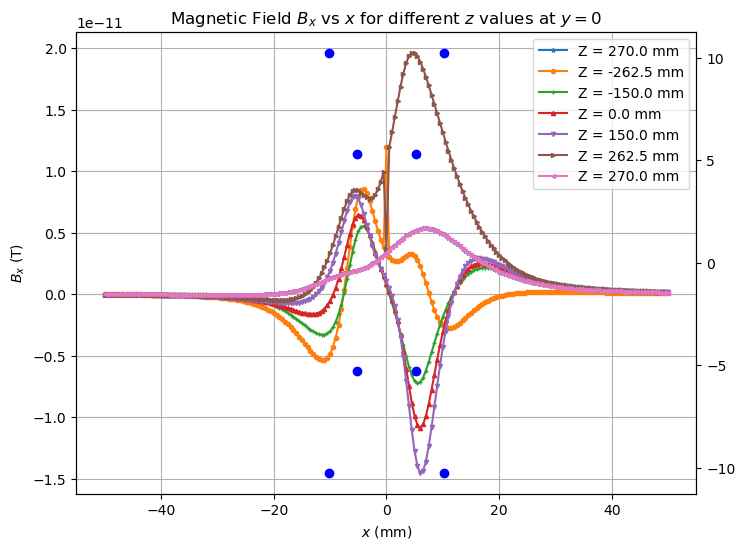

In [28]:
plot_B(field_map, 0)

In [29]:
at.NonlinearKicker(fam_name, length, energy, nslice, Filename_in=field_map_file)

TypeError: NonlinearKicker.__init__() takes 5 positional arguments but 6 were given